VINOD KUMAR K V

DEEP LEARNING EXAMINATION ON 09/06/2026

DS-06-VINOD_KUMAR.K.V(09/06/2026).ipynb

https://colab.research.google.com/drive/1D5o5YDcX6hpMnv9XG4K8CVaLk8RNuW0m?usp=sharing

In [ ]:
pip install scikit-learn

In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import fetch_california_housing
cal_housing = fetch_california_housing(as_frame=True)
X = cal_housing.data
y = cal_housing.target

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense


In [ ]:
x=pd.DataFrame(cal_housing.data)
y=pd.DataFrame(cal_housing.target)

EXPLONATORY DATA ANALYSYS (EDA)

In [ ]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
x.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [ ]:
x.size

165120

In [ ]:
x.shape

(20640, 8)

In [ ]:
x.duplicated(). sum()

np.int64(0)

In [ ]:
drop = x.drop_duplicates()
drop.shape

(20640, 8)

In [ ]:
#check missing values
x.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


In [ ]:
x.fillna(mean)

<Axes: xlabel='MedInc'>

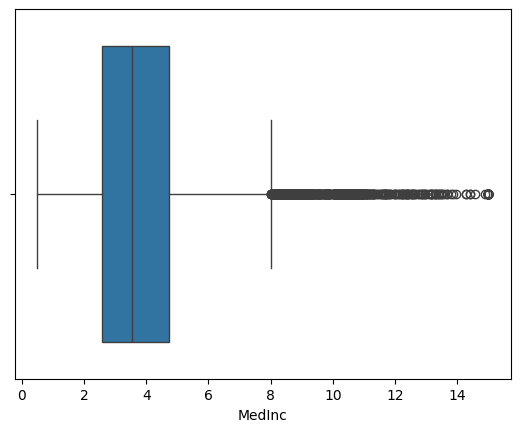

In [ ]:
#check outlier
sns.boxplot(x=x['MedInc'])

In [ ]:
#normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

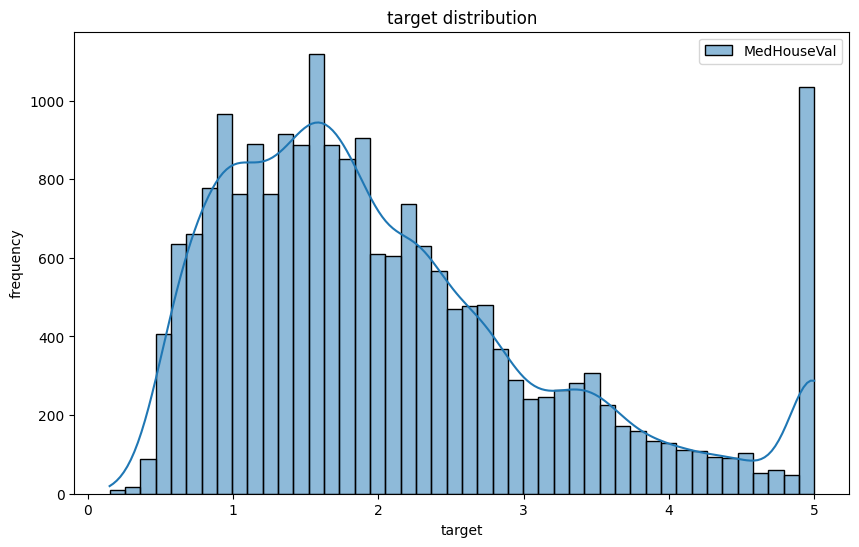

In [ ]:
#histogram
plt.figure(figsize=(10,6))
sns.histplot(y , kde=True)
plt.title('target distribution')
plt.xlabel('target')
plt.ylabel('frequency')
plt.show()

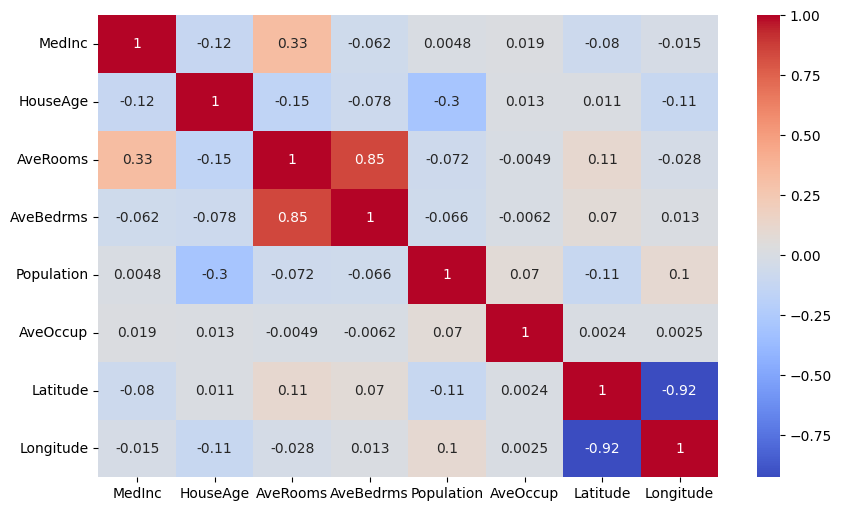

In [ ]:
#correlation heat map
plt.figure(figsize=(10,6))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm')
plt.show()


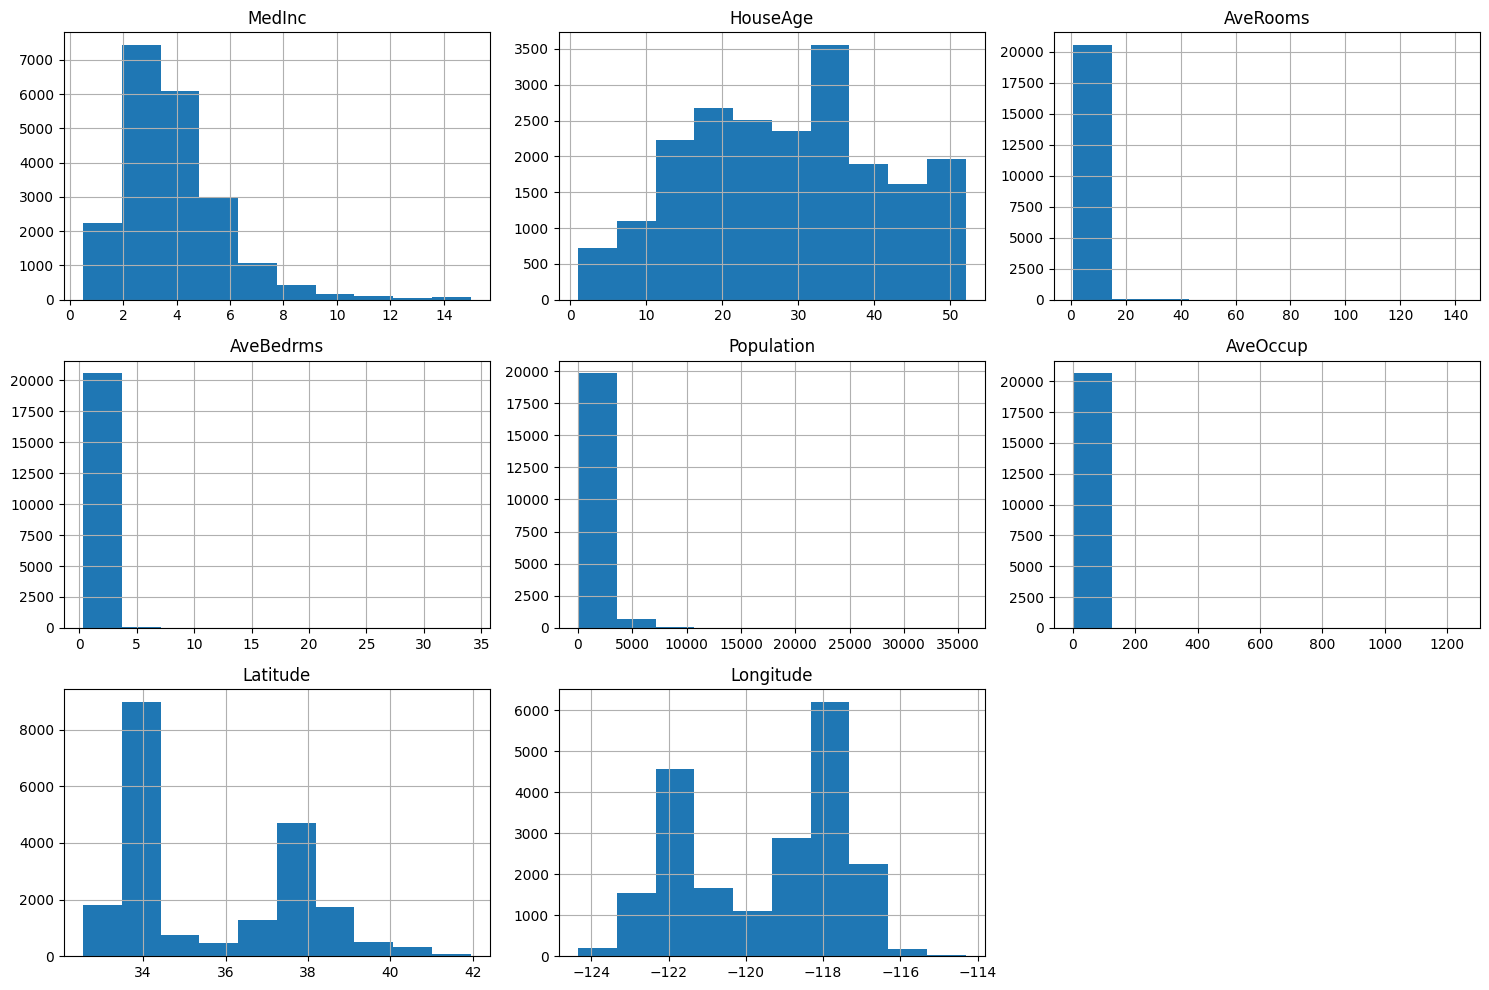

In [ ]:
# histogram for all features
x.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

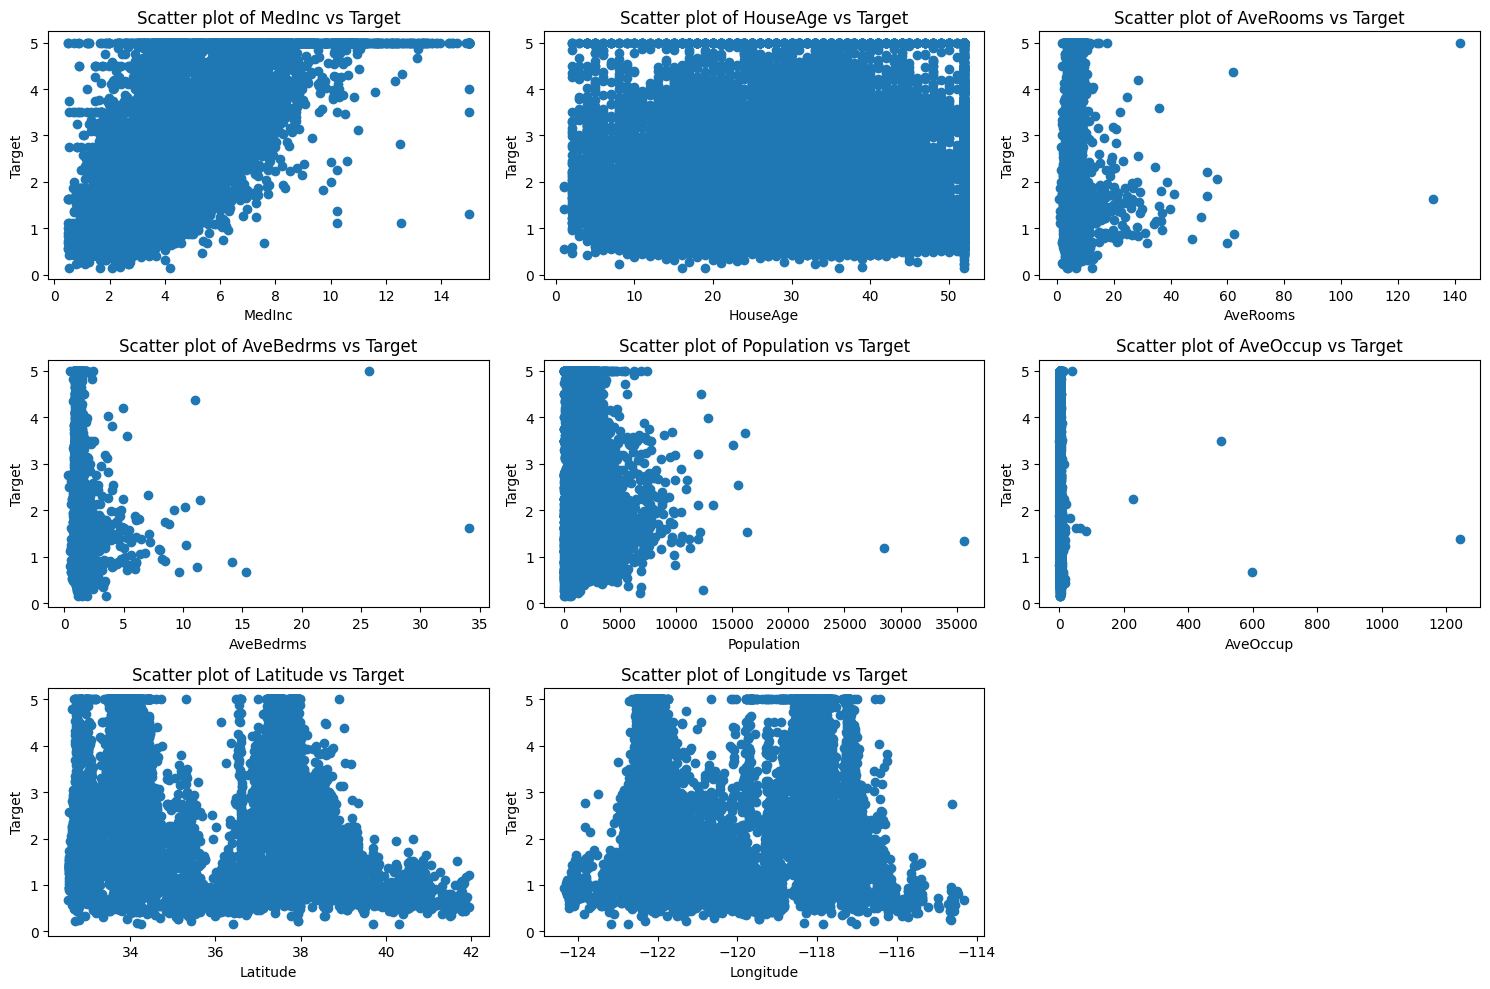

In [ ]:
#scatter plot
plt.figure(figsize=(15, 10))
for i, feature in enumerate(x.columns):
    plt.subplot(3, 3, i + 1) # Assuming there are 8 features, 3x3 grid
    plt.scatter(x[feature], y)
    plt.title(f'Scatter plot of {feature} vs Target')
    plt.xlabel(feature)
    plt.ylabel('Target')
plt.tight_layout()
plt.show()

MODEL BUILDING

In [ ]:
#Model Building
import tensorflow as tf
from tensorflow.keras import layers,models


In [ ]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(X_scaled.shape[1],)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [ ]:
#train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#

TRAINING ANN MODEL

In [ ]:
#model training
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
#

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.9384 - mean_absolute_error: 0.6489 - val_loss: 0.4533 - val_mean_absolute_error: 0.4751
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3948 - mean_absolute_error: 0.4480 - val_loss: 0.4065 - val_mean_absolute_error: 0.4494
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3787 - mean_absolute_error: 0.4331 - val_loss: 0.3912 - val_mean_absolute_error: 0.4449
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3557 - mean_absolute_error: 0.4245 - val_loss: 0.3947 - val_mean_absolute_error: 0.4324
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3458 - mean_absolute_error: 0.4157 - val_loss: 0.3944 - val_mean_absolute_error: 0.4297
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3746 - mean_absolute_error: 0.4118 - val_loss: 0.3657 - val_mean_absolute_error: 0.4231
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3257 - mean_absolute_error: 0.

EVALUATE THE MODEL

In [ ]:
#model evaluate
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')
#

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2753 - mean_absolute_error: 0.3526
Test Loss: 0.2752530872821808
Test MAE: 0.3525714576244354


In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(x_test)
r2_score(y_test, y_pred)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.7899487614631653

IMPROVED THE MODEL

In [ ]:
#improved
# Import necessary Keras components (already present in earlier imports but good to be explicit here)
from keras.models import Sequential
from keras.layers import Dense

# Define the improved Keras model with more layers
improved_model = Sequential()
improved_model.add(Dense(units=128, activation='relu', input_shape=(X_scaled.shape[1],)))
improved_model.add(Dense(units=64, activation='relu'))
improved_model.add(Dense(units=32, activation='relu'))
improved_model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#improved model compile
improved_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [ ]:
#improved model - model training
history = improved_model.fit(x_train, y_train, epochs=110, batch_size=32, validation_split=0.2)
#


Epoch 1/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7908 - mean_absolute_error: 0.5745 - val_loss: 0.4198 - val_mean_absolute_error: 0.4583
Epoch 2/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3698 - mean_absolute_error: 0.4327 - val_loss: 0.3831 - val_mean_absolute_error: 0.4346
Epoch 3/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3494 - mean_absolute_error: 0.4198 - val_loss: 0.3726 - val_mean_absolute_error: 0.4288
Epoch 4/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3509 - mean_absolute_error: 0.4077 - val_loss: 0.3585 - val_mean_absolute_error: 0.4097
Epoch 5/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3152 - mean_absolute_error: 0.3923 - val_loss: 0.3321 - val_mean_absolute_error: 0.3888
Epoch 6/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3063 - mean_absolute_error: 0.3847 - val_loss: 0.3211 - val_mean_absolute_error: 0.3999
Epoch 7/110
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3006 - mean_absolute_error: 0.3

In [ ]:
#improved model evaluate
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')
#

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2753 - mean_absolute_error: 0.3526
Test Loss: 0.2752530872821808
Test MAE: 0.3525714576244354


In [ ]:
#improved R square
from sklearn.metrics import r2_score
y_pred_improved = improved_model.predict(x_test)
r2_score(y_test, y_pred_improved)
#

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.793246328830719

----------------------------COMPLETED-----------------------------